## Исследование данных популярного сервиса аренды самокатов GoFast

## Analysis of Data from the GoFast Scooter Rental Service

Даны данные в которых содержится основная информация о некоторых пользователях, поездках и подписках сервиса.

#### Цель исследования:
Проанализировать данные и проверить некоторые гипотезы, которые, потенциально, могут помочь бизнесу вырасти.

##### Ход исследования:
Данные я получу из трёх датафреймов. О качестве данных ничего заранее не известно — перед выполнением целей я проведу обзор и обработку данных. Далее я объединю три датафрейма в один, добавлю некоторые столбцы для большей информативности данных, проведу несколько агрегаций. Затем приступлю к выполнению поставленной задачи.

Таким образом исследование будет проведено в шесть этапов:

- Описание данных
- Предобработка данных
- Исследовательский анализ данных
- Объединение данных
- Подсчёт выручки
- Проверка гипотез

---

The dataset contains basic information about certain users, trips, and subscriptions of the service.

#### Research Objective:
To analyze the data and test several hypotheses that could potentially help the business grow.

##### Research Plan:
The data will be obtained from three DataFrames. The quality of the data is unknown in advance, so before addressing the main objectives, I will review and preprocess the data. Then I will merge the three DataFrames into a single one, add several new columns to improve the informativeness of the dataset, and perform a number of aggregations. After that, I will proceed to solving the main analytical tasks.

Thus, the study will be carried out in six stages:

- Data description
- Data preprocessing
- Exploratory data analysis
- Data merging
- Revenue calculation
- Hypothesis testing

### Шаг 1. Загрузка данных.

In [1]:
#Импортируем библиотеки.
import pandas as pd #главная бибилиотека для анализа
import matplotlib.pyplot as plt #необходима для визуализации
import numpy as np #понадобится для некоторых математических операций
from scipy import stats as st #понадобится на шаге 6, для проведение статистических тестов

#### 1.1 Прочитаем файлы и сохраним их в переменные:

In [2]:
users_data = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
rides_data = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
subscriptions_data = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

#### 1.2 Изучим данные - для каждого датасета по отдельности: 
- Выведем первые 10 строк.
- Получим общую информацию.
- Напишем вывод.

In [3]:
#Изучим датасет с информацией о пользователях.
display(users_data.head(10))
display(users_data.info())

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


None

##### Вывод:
- Датасет прочитан корретно.
- Датасет содержит 1565 строк и 5 столбцов с информацией о: 
  - уникальном идентификаторе пользователя
  - имени
  - возрасте
  - городе
  - типе подписки
- Типы столбцов подобраны корректно относительно их содержания.

In [4]:
#Изучим датасет с информацией о поездках.
display(rides_data.head(10))
display(rides_data.info())

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


None

##### Вывод:
- Датасет прочитан корретно.
- Датасет содержит 18068 строк и 4 столбца с информацией о: 
  - уникальном идентификаторе пользователя
  - расстоянии, которое пользователь проехал в текущей сессии (в метрах)
  - продолжительности сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
  - дате совершения поездки.
- Тип столбца 'user_id' подобран корретно, в столбцах 'distance' и 'duration' можно поменять тип на int, если не содержится значений типа Nan или None, столбец date не является типом datetime64 библиотеки pandas - его нужно будет изменить.

In [5]:
#Изучим датасет с информацией о подписках.
display(subscriptions_data.head(10))
display(subscriptions_data.info())

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


None

##### Вывод:
- Датасет прочитан корретно.
- Датасет содержит 2 строки и 4 столбца с информацией о: 
  - типе подписки
  - стоимости одной минуты поездки по данной подписке
  - стоимости начала поездки
  - стоимости ежемесячного платежа
- Типы столбцов подобраны корректно относительно их содержания.

### Шаг 2. Предобработка данных.

#### 2.1 Изменим тип данных в столбце 'date' датасета с информацией о поездках:

In [6]:
rides_data['date'] = pd.to_datetime(rides_data['date'], format='%Y-%m-%d')

#### 2.2 Создадим новый столбец с номером месяца:

In [7]:
rides_data['month_number'] = rides_data['date'].dt.month

#### 2.3 Обработаем пропуски и дубликаты:

##### Разберемся с пропусками.

In [8]:
#Посчитаем количество пропусков в столбцах датафрейма с информацией о пользователях.
users_data.isnull().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [9]:
#Посчитаем количество пропусков в столбцах датафрейма с информацией о поездках.
rides_data.isnull().sum()

user_id         0
distance        0
duration        0
date            0
month_number    0
dtype: int64

In [10]:
#Посчитаем количество пропусков в столбцах датафрейма с информацией о подписках.
subscriptions_data.isnull().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

###### Вывод:
- Пропусков нету.

<s><span style="color:black">###### Примечание:
<s><span style="color:black">- Так-как пропусков, а соответственно и значений типа Nan и None нету в столбцах <s><span style="color:black">'distance'  и 'duration' - то изменим тип данных в них на int.</span>

In [11]:
#rides_data = rides_data.astype({
                                #'distance': int,
                                #'duration': int,
                               #}) 

##### Разберемся с дубликатами.

Датафрейм users_data:
- Столбец 'users_data' - уникальное имя пользователя, а значит каждое значение уникальное и надо произвести проверку на дубликаты.
- Столбцы 'name', 'age', 'city', 'subscription_type' содержат категориальные переменные, которые неприменно будут повторяться - проверку на дубликаты проводить не нужно
Датафрейм rides_data:
- Столбец 'users_data' - уникальное имя пользователя, но датафрейм содержит информацию о поездках, а один и тот же пользователь может совершать сколько угодно разных поездок - значит значения,скорее всего , будут повторяться - проверку на дубликаты проводить не нужно.
- Столбцы 'duration' и 'distance' содержат информацию о каждом времени и дистанции поездки - скорее всего эти значения каждый раз будут уникальными, так как в столбцы они записаны весьма точно - до метров и минут соответственно, а вероятность того, что подобная информация будет до такой точности идентична в разных поездках - крайне низка - в таком случае при наличии дубликатов это будет свидетельствовать о наличии ошибки в данных - проведём проверку.
- Столбец 'date' содержит информацию о дате - значения, вероятнее всего, будут повторяться и это допустимо - проверка не требуется.
Датафрейм subscriptions_data:
- Проверка на дубликаты не требуется.

In [12]:
#Посчитаем количество дубликатов в столбце 'user_id' датафрейма с информацией о пользователях.
users_data.duplicated().sum()

31

###### Вывод:
- Количество дубликатов менее 2% от количества строк датафрейма - маленькая доля не влияющая на датасет в целом.
- Каждый пользователь уникален - заменить дубликаты ничем нельзя - удаляем, оставив только первое встреченное уникальное значение.

In [13]:
#Посчитаем количество дубликатов в столбце 'distance' датафрейма с информацией о поездках.
rides_data['distance'].duplicated().sum()

0

###### Вывод:
- Дубликатов не обнаружено.

In [14]:
#Посчитаем количество дубликатов в столбце 'duration' датафрейма с информацией о поездках.
rides_data['duration'].duplicated().sum()

94

###### Вывод:
- Количество дубликатов менее 0.5% от количества строк датафрейма.
- Логичнее всего строки с дубликатами удалить - похоже на ошибку в данных.

In [15]:
#Удаляем строки датафрейма 'users_data' с дубликатами в столбце 'user_id'.
#users_data = users_data.drop_duplicates(subset=['user_id'])

In [16]:
#Удаляем строки датафрейма 'rides_data' с дубликатами в столбце 'duration'.
#rides_data = rides_data.drop_duplicates(subset=['duration'])

#### Общий вывод раздела:
- Мы произвели обработку данных. Изначальное качество данных было хорошее - в данных не так много ошибок и дубликатов. Пропуски отсутствовали польностью.

###  Шаг 3. Исследовательский анализ данных.
- Опишем и визуализируем общую информацию о пользователях и поездках:

#### 3.1 Частота встречаемости городов:

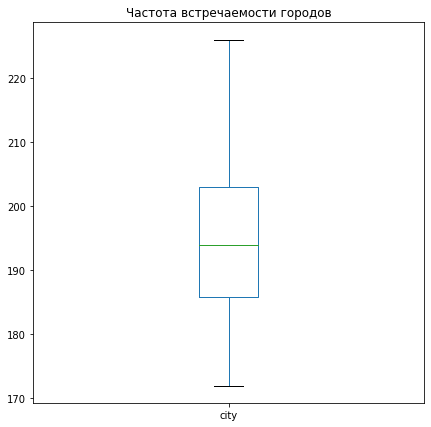

In [17]:
#Для уникальных значений столбца 'city' в датафрейме 'users_data' посчитаем их количество и построим ящик с усами.
users_data['city'].value_counts().plot(
                                      kind='box', 
                                      title='Частота встречаемости городов', 
                                      figsize=(7,7)
                                      );

###### Вывод:
- Частота имеет медиану ≈ 190
- Большая часть значений(первый и третий квартили) находятся в диапазоне примерно от 180 до 200.
- Размах значений около 50.
- Минимальное значение ≈ 170, максимальное ≈ 220. 
- Выбросов или аномалий не наблюдается.

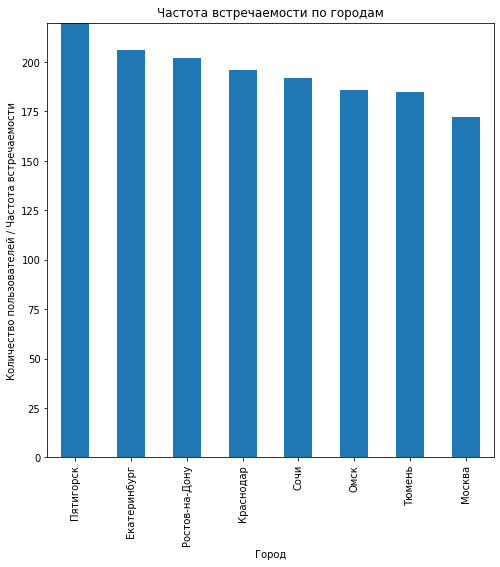

In [18]:
#Оценим частоту встречаемости по городам, построив гистрограмму распределения.
users_data['city'].value_counts().sort_values(ascending=False).plot(
                                                                    kind='bar', 
                                                                    title='Частота встречаемости по городам', 
                                                                    figsize=(8,8),
                                                                    )
#Настроим отображение гистрограммы.
plt.ylim(0, 220)
#Добавим подписи осей.
plt.xlabel('Город', fontsize=10)
plt.ylabel('Количество пользователей / Частота встречаемости', fontsize=10);

###### Вывод:
- Наиболее встречаемый город Пятигорск.
- Наименее встречаемый город Москва.
- Общая частота встречаемости для всех городов схожа.

#### 3.2 Cоотношение пользователей с подпиской и без подписки:

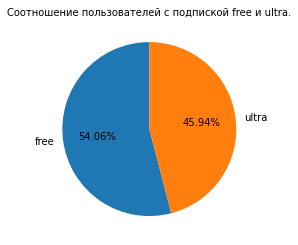

In [19]:
#Построим круговую диаграмму, отображающую проценты пользователей с подписками free и ultra.
plt.pie(
        users_data['subscription_type'].value_counts(), #для уникальных значений столбца 'subscription_type' посчитаем количество
        labels=users_data['subscription_type'].value_counts().index , #типы подписок - это индексы
        autopct='%1.2f%%', #настроим отображение в % с двумя знаками после запятой
        startangle=90 #определим угол, с которого начинается первый сегмент
        )
plt.title('Cоотношение пользователей с подпиской free и ultra.', fontsize=10);

###### Вывод:
- Хоть пользователей без подписки большее количество, однако не на много, соотношение очень близкое. 
- Пользователи пользуются подпиской ульта почти так же часто как бесплатной.

#### 3.3 Возраст пользователей:

count    1565.000000
mean       24.922045
std         4.553496
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

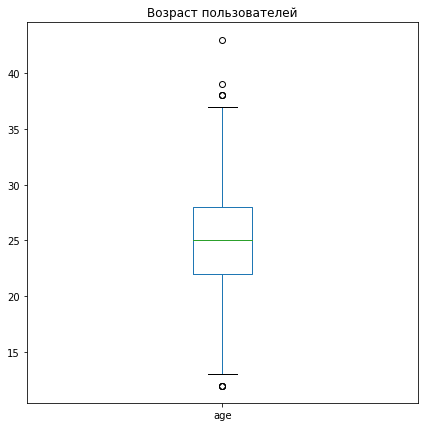

In [20]:
#Построим ящик с усами для столбца 'age'.
users_data['age'].plot(
                       kind='box', 
                       title='Возраст пользователей', 
                       figsize=(7,7)
                       )
#Вызовем метод describe для отображения точных значений описательной статистики.
users_data['age'].describe()

###### Вывод:
- Средний и медианный возраст пользователей примерно равны - около 25 лет.
- Большая часть пользователей примерно от 22 до 28 лет.
- Разброс пользователей примерно 20 лет.
- Минимальное значение ≈ 12, максимальное ≈ 43. На ящике они отображены как выброс. Аномалией - это точно не является - вполне реальный возраст для управления самокатом.
- Итоги:
  - Основая аудитория пользователей - это молодёж.

#### 3.4 Расстояние, которое пользователь преодолел за одну поездку:

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

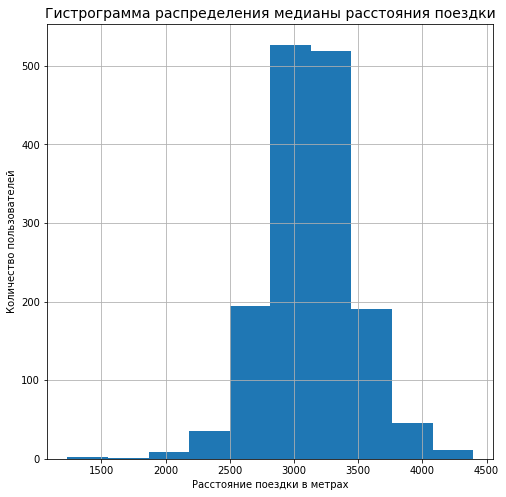

In [21]:
#Выведем describe для точных значений описательной статистики.
display(rides_data['distance'].describe())

#Сделаем сводную таблицу с медианой поездок по пользователям и построим по ней гистрограмму распределения.
rides_data.pivot_table(
                       index='user_id', 
                       values='distance', 
                       aggfunc=('median')).hist(figsize=(8,8))

#Добавим подписи осей и заголовок.
plt.xlabel('Расстояние поездки в метрах', fontsize=10)
plt.ylabel('Количество пользователей', fontsize=10)
plt.title('Гистрограмма распределения медианы расстояния поездки', fontsize=14);

###### Вывод:
- Среднее значение длины поездки в 3070 весьма точно описывает диапазон медианной дистанции по пользователям примерно от 2900 до 3400 метров, а по гистрограмме видно, что наибольшая часть значений сосредоточена именно там, и значения выше или ниже этого диапазона встречаются крайне редко.
- Стандартное отклонение примерно 1116 метров.
- Максимальное значение 7211 метров за поездку - выброс, не аномалия.
- Минимальное значение 0 - вероятно некоторые поездки заканчиваются не успев начаться.

#### 3.5  Продолжительность поездок:

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

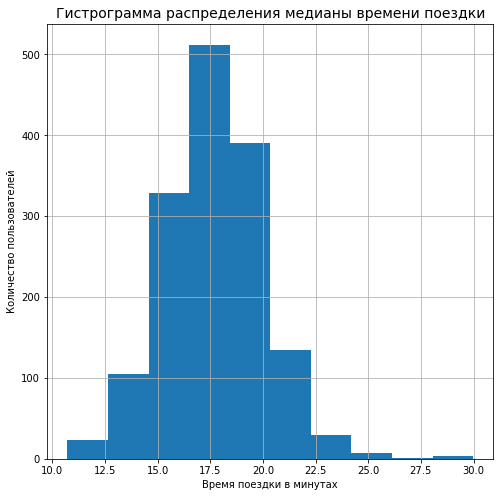

In [22]:
#Выведем describe для точных значений описательной статистики.
display(rides_data['duration'].describe())

#Сделаем сводную таблицу с медианой поездок по пользователям и построим по ней гистрограмму распределения.
rides_data.pivot_table(index='user_id', values='duration', aggfunc=('median')).hist(figsize=(8,8))

#Добавим подписи осей и заголовок.
plt.xlabel('Время поездки в минутах', fontsize=10)
plt.ylabel('Количество пользователей', fontsize=10)
plt.title('Гистрограмма распределения медианы времени поездки', fontsize=14);

###### Вывод:
- Среднее время поездки примерно 17 минут.
- Стандартное отклонение примерно 6 минут.
- Диаграмма распределение, а так же значения первого и третьего квартилей, показывают диапазон наиболее встечающегося времени поездки в диапазоне примерно от 13 до 21 минуты.
- Максимальное значение в 40 минут - выброс, не аномалия - весьма реальное время для поездки.
- Минимальное значение в 0 минут - видимо связано с минимальным расстоянием поездки в 0 метров.

### Шаг 4. Объединение данных:

#### 4.1 Объединим данные о пользователях, поездках и подписках в один датафрейм:

In [23]:
#Объедим датафреймы о поездках и пользователях по столбцу уникального идентификаторы пользователя,
#cохранм новый датафрейм в переменную.
total_data = pd.merge(rides_data, users_data, on='user_id', how='inner')

#Теперь получившийся новый датафрейм объедим с датафреймом с информацией о подписках по столбцу 'subscription_type',
#и cохранм обратно в переменную.
total_data = pd.merge(total_data, subscriptions_data, on='subscription_type', how='inner')

In [24]:
#Проверка размерности
print('Общее количество строк трёх датафреймов до объединения:')
print(len(rides_data))
print('Количество строк объединённого датафрейма total_data:')
print(len(total_data))
print()

if len(users_data.columns) + len(rides_data.columns) + len(subscriptions_data.columns) - 2 == len(total_data.columns):
    print('Количество столбцов объединённого датафрейма total_data правильное:')
    print(len(total_data.columns))
else:
    print('Количество столбцов объединённого датафрейма total_data неправильное:')
    print(len(total_data.columns))

Общее количество строк трёх датафреймов до объединения:
18068
Количество строк объединённого датафрейма total_data:
18388

Количество столбцов объединённого датафрейма total_data правильное:
12


In [25]:
total_data.head(5)

,user_id,distance,duration,date,month_number,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199


###### Вывод:
- Количество столбцов верное.
- Количество строк результутирующего датафрейма умешилось относительно общего количества строк трех датафреймов до объединения. При использовании метода merge для объединения мы использовали аргумент inner(так-же он ставится по умолчанию), при его использование внутреннее объединение возвращает строки, которые имеют общие значения в ключевом столбце (или столбцах) в обоих датафреймах, полагаю, в нашем случае это более подходящих аргумент ведь строки с неполной информацией не несут информативности для дальнейший целей, в рамках осуществления которых и был создан объединённый датафрейм.
- При выводе первых 5 строк результутирующего датафрейма и ознакомления с ними - не было замечено ошибок.

#### 4.2 Создадим ещё два датафрейма из датафрейма, созданного на этапе 4.1:
1. C данными о пользователях без подписки;
2. С данными о пользователях с подпиской.

In [26]:
#Сохраним в переменную total_free_data только те строки в которых значения в столбце 'subscription_type' = 'free'
total_free_data = total_data[total_data['subscription_type'] == 'free']

#Сохраним в переменную total_free_data только те строки в которых значения в столбце 'subscription_type' = 'ultra'
total_ultra_data = total_data[total_data['subscription_type'] == 'ultra']

#### 4.3 Визуализируем  информацию о расстоянии и времени поездок для пользователей обеих категорий.

##### Для подписки ultra:

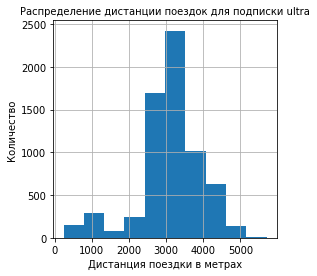

In [27]:
#Построим гистрограмму распределения.
total_ultra_data['distance'].hist(figsize=(4,4))

#Добавим подписи осей и заголовок.
plt.xlabel('Дистанция поездки в метрах', fontsize=10)
plt.ylabel('Количество', fontsize=10)
plt.title('Распределение дистанции поездок для подписки ultra', fontsize=10);

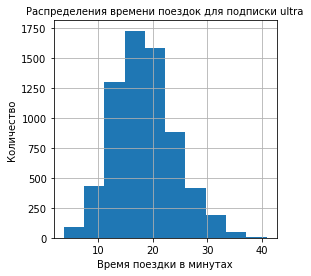

In [28]:
#Построим гистрограмму распределения.
total_ultra_data['duration'].hist(figsize=(4,4))

#Добавим подписи осей и заголовок.
plt.xlabel('Время поездки в минутах', fontsize=10)
plt.ylabel('Количество', fontsize=10)
plt.title('Распределения времени поездок для подписки ultra', fontsize=10);

##### Для подписки free:

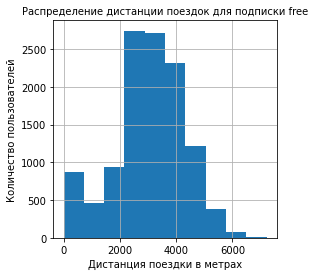

In [29]:
#Построим гистрограмму распределения.
total_free_data['distance'].hist(figsize=(4,4))

#Добавим подписи осей и заголовок.
plt.xlabel('Дистанция поездки в метрах', fontsize=10)
plt.ylabel('Количество пользователей', fontsize=10)
plt.title('Распределение дистанции поездок для подписки free', fontsize=10);

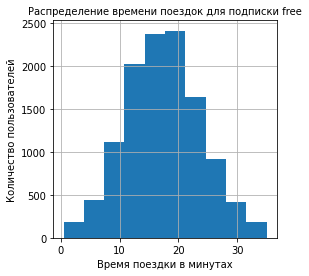

In [30]:
#Построим гистрограмму распределения.
total_free_data['duration'].hist(figsize=(4,4))

#Добавим подписи осей и заголовок.
plt.xlabel('Время поездки в минутах', fontsize=10)
plt.ylabel('Количество пользователей', fontsize=10)
plt.title('Распределение времени поездок для подписки free', fontsize=10);

##### Выводы:
- Гистрограммы распределения и времени, и дистанции для поездок с типом подписки free и ultra различаются "резкостью ступенек", у подписок ультра большая часть значений расположена вокруг одного среднего и далее идёт резкий переход к другим значениями, а у подписок free эти переходы более плавные, и распределение более децентрализовано. Полагаю, это связано с тем, что пользователи покупающие подписку берут её под конректные цели - проезжать определённое расстояние, заранее предполагая, что они будут это делать, в то время как пользователи подписки free - это, скорее, не постонянные клиенты, а пользователи иногда берущие самокат без чётких целей, и соответственно имеющие более случайное и плавное распределение.
- Конкретика:
  - Пользователи подписки ultra чаще всего проезжают расстояние около 3500 метров, крайне редко менее 2500, и иногда более 4000 метров.
  - Пользователи подписки free имеют более широкий диапазон значений, наиболее часто встречающиеся расстояния поездки примерно от 2000 до 4500 метров.
  - Пользователи подписки ultra чаще всего совершают поездки примерно от 10 до 20 минут, но наибольшая концентрация поездок около 20 минут.
  - Пользователи подписки free имеют более широкий диапазон значений примерно от 10 до 30 минут, где значения распределены более плавно чем у пользователей с подпиской ultra.

### Шаг 5. Подсчёт выручки:

####  5.1 Создадим датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными из шага 4: найдем суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.

In [31]:
#Округлим продолжительность каждой поездки в большую сторону перед агрегацией.
total_data['duration'] = np.ceil(total_data['duration']) 

In [32]:
#Создадим сводную таблицу методом pivot_table из общего датафрейма 'total_data', с информацией агрегированной
#по уникальному идентификатору пользователя, а так же номеру месяца.
#Сохраним таблицу в переменную agg_data.
agg_data = total_data.pivot_table(index=('user_id', 'month_number'), values=('distance', 'duration', 'date'), 
                                  aggfunc={'distance': 'sum', 'duration':'sum', 'date': 'count'})
#Переименуем названия столбцов в соответствии с его содержанием.
agg_data.columns = ['rides_counts', 'total_distance', 'total_durations']
#Избавимся от мультииндексов - сбросив индексы.
agg_data = agg_data.reset_index()

####  5.2 В этот же датафрейм добавим столбец с помесячной выручкой:

In [33]:
#Напишем цикл for, который будет возвращать значения из результата выполнения формулы расчета
#выручки по месяцам для пользователей в столбец 'revenue' датасета agg_data.
for revenue in agg_data:
    #Значения: стоимость старта поездки, стоимость одной минуты поездки, стоимость подписки; 
    #цикл будет брать из локальной переменной database, в которую мы сохраним сводную таблицу
    #из датафрейма 'total_data', использующую в значениях индексов столбцы 'user_id','month_number' и
    #соотвественно агрегированную по ним, сбросим индексы, и сможем сравнить два датафрейма,
    #и соотвественно заполнить значения столбца 'revenue' формулой в которой используются
    #значения из обоих.
    database = total_data.pivot_table(
                                     index=('user_id','month_number', 'subscription_type'), 
                                     values=('minute_price', 'start_ride_price', 'subscription_fee')
                                     ).reset_index()
    #Используем формулу: стоимость старта поездки ×  количество поездок 
                        #+
                        #стоимость одной минуты поездки × общая продолжительность всех поездок в минутах 
                        #+ 
                        #стоимость подписки
    agg_data['revenue'] = (database['start_ride_price'] * agg_data['rides_counts'] 
                           +
                           database['minute_price'] * agg_data['total_durations'] 
                           + 
                           database['subscription_fee'])
    #Добавим в этот датафрейм столбец с типом подписки, хоть этого и не было в задание,
    #но он нам понадобится в дальнейшем в шаге 6.3 для проверки гипотезы.
    agg_data['subscription_type'] =  database['subscription_type']

#### Вывод:
- Создан новый датафрейм - 'agg_data', с агрегированной информацией из общего датафрейма о суммарном расстоянии, количестве поездок, суммарном времени поездок, типе подписки для каждого пользователя, за каждый месяц, а так-же суммарной выручки полученной с каждого пользователя, за каждый месяц сервисом по аренде.

### Шаг 6. Проверка гипотез:

#### 6.1:
- Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверьте гипотезу. Используйте исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

##### Формулировка гипотез:
- Нулевая гипотеза (H0): Среднее время поездок для пользователей с подпиской равно среднему времени поездок для пользователей без подписки.
- Альтернативная гипотеза (H1): Среднее время поездок для пользователей с подпиской ultra больше среднего времени поездок пользователей с подпиской free.

In [34]:
#Проведем t-тест для двух генеральных выборок из столбцов 'duration' в датасетах,
#содержащих информацию о пользователях с подписками free и ultra.
alpha = 0.05 #уровень значимости
results_one = st.ttest_ind(total_ultra_data['duration'], total_free_data['duration'], alternative='greater')

#Выведем значение pvalue
print('p-значение:', results_one.pvalue)

#Выводим вывод
if results_one.pvalue < alpha: 
    print('Отвергаем нулевую гипотезу, в пользу альтернативной')
else:
    print('Не получилось отвергнуть нулевую гипотезу');

p-значение: 1.6261032773552045e-34
Отвергаем нулевую гипотезу, в пользу альтернативной


##### Выводы:
- pvalue ≈ 1.6261032773552045e-34 или ≈ 0.00000000000000000000000000000000001.6261032773552045e.
- На основе этих результатов можно сделать вывод о статистически значимых различиях между двумя группами данных - значение p-value крайне малое, что позволяет отвергнуть нулевую гипотезу в пользу альтернативной, подтверждая наличие различий между группами.

#### 6.2:
- Расстояние одной поездки в 
3130
3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 
3130
3130 метров? Проверьте гипотезу и сделайте выводы.

##### Формулировка гипотез:
- Нулевая гипотеза (H0): Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку не превышает 3130 метров.
- Альтернативная гипотеза (H1): Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку превышает 3130 метров.

In [38]:
#Проведем одновыборочный t-тест.
alpha = 0.05 #уровень значимости
results_two = st.ttest_1samp(total_ultra_data['distance'], 3130, alternative='greater')

#Выведем значение pvalue
print('p-значение:', results_two.pvalue)

if results_two.pvalue < alpha: 
    print('Отвергаем нулевую гипотезу, в пользу альтернативной')
else:
    print('Не получилось отвергнуть нулевую гипотезу');

p-значение: 0.9224525735508029
Не получилось отвергнуть нулевую гипотезу


##### Выводы:
- pvalue ≈ 0.092, что выше значения alpha - уровня статистической значимости = 0.05.
- Это означает, что нет статистически значимых доказательств того, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку  превышает расстояния в 3130 метров.
- Нулевую гипотезу не отвергаем в пользу альтернативной.

#### 6.3:
-  Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. 

##### Формулировка гипотез:
- Нулевая гипотеза (H0): Средняя помесячная выручка от пользователей с подпиской равна средней помесячной выручке от пользователей без подписки.
- Альтернативная гипотеза (H1): Средняя помесячная выручка от пользователей с подпиской выше, чем средняя помесячная выручка от пользователей без подписки.

In [37]:
#Проведем t-тест.
alpha = 0.05 #уровень значимости
results_three = st.ttest_ind(
                             #Получаем значения столбца выручки для пользователей с подпиской ultra
                             agg_data.query('subscription_type == "ultra"')['revenue'], 
                             #Получаем значения столбца выручки для пользователей с подпиской free
                             agg_data.query('subscription_type == "free"')['revenue'], 
                             alternative='greater'
                             )

#Выведем значение pvalue
print('p-значение:', results_three.pvalue)

#Выводим вывод
if results_three.pvalue < alpha: 
    print('Отвергаем нулевую гипотезу, в пользу альтернативной')
else:
    print('Не получилось отвергнуть нулевую гипотезу');

p-значение: 4.227438894541132e-29
Отвергаем нулевую гипотезу, в пользу альтернативной


##### Выводы:
- pvalue ≈ 1.1914705742669238e-43 ≈ 0.000000000000000000000000000000000000000011914705742669238, намного меньше  используемого уровня значимости alpha = 0.05.
- Это означает, что у нас есть статистически значимые доказательства в пользу того, что помесячная выручка от пользователей с подпиской отличается от помесячной выручки от пользователей без подписки.
- Таким образом, мы отвергаем нулевую гипотезу в пользу альтернативной гипотезы.

#### 6.4:
##### Вопрос:
- Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

##### Ответ:
- Эта гипотеза будет являться - гипотезой о равенстве средних для зависимых (парных) выборок.
- Для проверки этой гипотезы нам понадобиться использовать парный t-тест.
- Чтобы проверить эту гипотезу в Python, мы применим метод scipy.stats.ttest_rel().
- Примечание:
  - Данному методу достаточно передать всего два параметра: наборы данных до и после. Оба набора должны быть одинаковыми по размеру: каждое измерение должно быть проведено до и после изменения.
  - Подразумевается, что порядок объектов, для которых сделаны измерения, в обоих массивах тоже одинаковый.

### Шаг 7. (необязательное задание). Распределения:
- Не стал делать так как оно необязательное - а я пытаюсь успеть к жёсткоу дедлайну.

### Шаг 8. Общий вывод:

####  Было проведено исследование данных из сервиса по аренде самокатов, данные содержались в трёх датасетах, задача звучала так:
##### - Необходимо проанализировать данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.

1. На первом этапе данные из трёх датасетов были прочитаны с помощью библиотеки Pandas и сохранены в переменные. Далее была изучена и описана общая информация о каждом из датасетов.
2. Вторым этапом была предобработка данных — сначала мы выполнили приведение типов, затем создали новый столбец с номером месяца для повышения информативности, после чего проверили и обработали пропущенные значения и дубликаты.
3. Третьим этапом был исследовательский анализ данных. Мы описали и визуализировали:
   - частоту встречаемости городов;
   - соотношение пользователей с подпиской и без подписки;
   - возраст пользователей;
   - расстояние, которое пользователь преодолел за одну поездку;
   - продолжительность поездок.
4. Четвёртым этапом было объединение данных. Мы объединили три датасета с данными о пользователях, поездках и подписках в один датафрейм. Далее создали ещё два датафрейма:
   - с данными о пользователях без подписки;
   - с данными о пользователях с подпиской.
   Также была проведена визуализация расстояния и времени поездок для обеих категорий пользователей.
5. Пятым этапом был подсчёт выручки. Мы сформировали датасет с агрегированными данными о поездках, пользователях и выручке.
6. Шестым этапом была проверка гипотез. Мы проверили три гипотезы, которые потенциально могут способствовать росту бизнеса: часть из них была подтверждена, часть — опровергнута. Также был дан ответ на дополнительный вопрос, связанный с оптимальным решением поставленной задачи.

---

####  A study was conducted using data from a scooter rental service, which consisted of three datasets. The task was as follows:
##### - To analyze the data and test several hypotheses that could potentially help the business grow.

1. At the first stage, the data from three datasets were loaded using the Pandas library and stored in variables. The general structure and content of each dataset were then explored and described.
2. At the second stage, data preprocessing was performed. This included type conversion, creation of a new column representing the month number to enhance data informativeness, and handling of missing values and duplicates.
3. The third stage involved exploratory data analysis. The following aspects were analyzed and visualized:
   - frequency distribution of cities;
   - proportion of users with and without subscriptions;
   - user age distribution;
   - distance traveled per trip;
   - trip duration.
4. At the fourth stage, the datasets were merged. The three datasets (users, trips, and subscriptions) were combined into a single DataFrame. Two additional subsets were created:
   - users without subscriptions;
   - users with subscriptions.  
   Visualizations comparing trip distance and duration between these groups were also produced.
5. At the fifth stage, revenue was calculated by creating a dataset with aggregated information on trips, users, and revenue.
6. At the sixth stage, hypothesis testing was performed. Three hypotheses relevant to business growth were evaluated: some were confirmed, while others were rejected. An additional business-related question was also addressed.